# Notebook 04 - TF-IDF Baseline Models

## Environment Setup and Library Imports (Baseline Models)

This section initialises the environment and imports all required libraries for baseline machine learning models and text feature extraction.

- Extends the Python path to enable access to project modules
- Imports core libraries for:
  - Data manipulation and numerical computation
  - Visualisation using Matplotlib and Seaborn
  - Model training and evaluation with scikit-learn
- Loads text vectorisation tools for TF-IDF feature extraction
- Imports baseline models:
  - Logistic Regression
  - Random Forest
  - Linear Support Vector Classifier
- Includes calibration utilities for probability estimation
- Loads evaluation metrics for classification and ranking performance
- Handles class imbalance using computed class weights
- Initialises NLTK stopwords for text preprocessing
- Loads project configuration parameters for reproducibility
- Creates output directories for saving model results and plots
- Defines global plotting style and colour palette for consistency

In [1]:
# System Path Configuration 
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

# Core Data Handling Libraries
import pandas as pd
import numpy as np

# Visualisation Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities 
import pickle
import warnings
warnings.filterwarnings('ignore')  # suppress warnings

# Model Selection Utilities
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

# Text Feature Extraction (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer

# Machine Learning Models (Baselines)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Probability Calibration
from sklearn.calibration import CalibratedClassifierCV

# Evaluation Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay,
)

# Class Imbalance Handling
from sklearn.utils.class_weight import compute_class_weight

# NLTK Stopwords Setup
import nltk
nltk.download('stopwords', quiet=True)

from nltk.corpus import stopwords

# Project Configuration Parameters
from config import (
    LABELLED_DATASET,
    PROCESSED_DIR,
    BEST_BASELINE_PKL,
    BASELINE_RESULTS_CSV,
    PLOTS_DIR,
    TEST_SIZE,
    VAL_SIZE,
    RANDOM_STATE,
)

# Output Directory for Baseline Model Visualisations
BASELINE_MODEL_PLT = PLOTS_DIR / "baseline_model"
BASELINE_MODEL_PLT.mkdir(parents=True, exist_ok=True)

# Global Plot Styling
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# Colour Palette for Visualisations
PALETTE = ['#2E86AB', '#E84855', '#F4A261', '#2A9D8F', '#8338EC']

# Stopwords List
STOP = list(stopwords.words('english'))

## Data Loading and Stratified Splitting

This section loads the labelled dataset, extracts features and labels, and prepares stratified data splits for baseline model training.

- Reads the dataset from disk and verifies its dimensions
- Extracts:
  - Text narratives as input features
  - Binary readmission labels as targets
- Performs a two-stage stratified split to create:
  - Training set
  - Validation set
  - Test set
- Outputs dataset size, class distribution, and positive class rate
- Computes class weights to address label imbalance in the training data

In [2]:
# Dataset Loading
dataset = pd.read_csv(LABELLED_DATASET)
print(f'Loaded: {dataset.shape}')

# Feature and Label Extraction
X = dataset['narrative'].astype(str).to_numpy()
y = dataset['readmission_30d'].astype(int).to_numpy()

# Train / Validation / Test Split (Stratified)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

# Dataset Summary Statistics
print(f'Train : {len(X_train):,} | Val : {len(X_val):,} | Test : {len(X_test):,}')
print(f'Train label dist : {np.bincount(y_train)}')
print(f'Positive rate : {y_train.mean()*100:.1f}%')

# Class Weight Computation (Handling Imbalance)
cw_arr = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

cw_dict = {
    0: float(cw_arr[0]),
    1: float(cw_arr[1])
}

print(f'Class weights : {cw_dict}')

Loaded: (36096, 10)
Train : 28,876 | Val : 3,610 | Test : 3,610
Train label dist : [23325  5551]
Positive rate : 19.2%
Class weights : {0: 0.6189924973204716, 1: 2.600972797694109}


## TF-IDF Feature Extraction

This section converts textual data into numerical feature representations using TF-IDF vectorisation.

- Initialises a TF-IDF vectoriser with:
  - Unigrams and bigrams to capture contextual patterns
  - Maximum feature limit to control dimensionality
  - Stopword removal for noise reduction
  - Sublinear term frequency scaling
  - Minimum document frequency threshold to filter rare terms
- Fits the vectoriser on the training data and applies the transformation to:
  - Training set
  - Validation set
  - Test set
- Outputs the resulting sparse matrix dimensions for verification

In [3]:
# TF-IDF Vectoriser Initialisation
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    stop_words=STOP,
    sublinear_tf=True,
    min_df=3,
)

# Fit on Training Data and Transform Splits
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

# TF-IDF Matrix Shapes
print(f"TF-IDF train matrix : {X_train_tfidf.shape}")
print(f"TF-IDF test  matrix : {X_test_tfidf.shape}")

TF-IDF train matrix : (28876, 15000)
TF-IDF test  matrix : (3610, 15000)


## Baseline Model Training and Evaluation

This section defines baseline machine learning models and evaluates their performance on TF-IDF features.

- Defines three baseline models:
  - Logistic Regression
  - Random Forest
  - Linear SVM with probability calibration
- Applies class weighting to handle label imbalance
- Trains each model on the TF-IDF training features
- Generates predictions and class probabilities on the test set
- Computes evaluation metrics including:
  - ROC-AUC
  - Precision-Recall AUC
  - Classification report (precision, recall, F1-score)
- Stores model outputs and metrics for comparison
- Outputs performance metrics for each model

In [4]:
# Baseline Model Definitions
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        C=1.0,
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        max_features="sqrt",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Linear SVM": CalibratedClassifierCV(
        LinearSVC(
            class_weight="balanced",
            max_iter=3000,
            random_state=RANDOM_STATE,
            C=0.5,
        ),
        cv=3,
    ),
}

# Model Training and Evaluation Loop
results = {}

for name, model in models.items():
    print(f"Training {name}...")

    # Model Training
    model.fit(X_train_tfidf, y_train)

    # Predictions and Probabilities
    y_pred = model.predict(X_test_tfidf)
    y_prob = model.predict_proba(X_test_tfidf)[:, 1]

    # Evaluation Metrics
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc  = average_precision_score(y_test, y_prob)

    # Classification Report
    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0,
    )

    # Store Results
    results[name] = {
        "model"  : model,
        "y_pred" : y_pred,
        "y_prob" : y_prob,
        "roc_auc": roc_auc,
        "pr_auc" : pr_auc,
        "report" : report,
    }

    # Output Metrics
    print(f"  ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f}")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Not Readmitted", "Readmitted"],
            zero_division=0,
        )
    )

Training Logistic Regression...
  ROC-AUC: 0.7021 | PR-AUC: 0.3882
                precision    recall  f1-score   support

Not Readmitted       0.87      0.73      0.79      2916
    Readmitted       0.33      0.56      0.41       694

      accuracy                           0.69      3610
     macro avg       0.60      0.64      0.60      3610
  weighted avg       0.77      0.69      0.72      3610

Training Random Forest...
  ROC-AUC: 0.6776 | PR-AUC: 0.3744
                precision    recall  f1-score   support

Not Readmitted       0.86      0.76      0.80      2916
    Readmitted       0.31      0.46      0.37       694

      accuracy                           0.70      3610
     macro avg       0.58      0.61      0.59      3610
  weighted avg       0.75      0.70      0.72      3610

Training Linear SVM...
  ROC-AUC: 0.6912 | PR-AUC: 0.3666
                precision    recall  f1-score   support

Not Readmitted       0.81      1.00      0.89      2916
    Readmitted       0.

## Cross-Validation and Model Stability Assessment

This section evaluates baseline models using stratified cross-validation to assess performance stability and generalisation.

- Defines a stratified k-fold cross-validation strategy:
  - Preserves class distribution across folds
  - Uses 5 folds with shuffling for robustness
- Performs cross-validation for each baseline model
- Computes evaluation metrics across folds:
  - Weighted F1-score
  - ROC-AUC
- Reports mean and standard deviation for each metric
- Provides insight into:
  - Model consistency
  - Sensitivity to data variation

In [5]:
# Cross-Validation Strategy (Stratified K-Fold)
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

# Cross-Validation for Each Model
for name, model in models.items():
    print(f"Cross-validating {name}...")

    # Perform Cross-Validation (Multiple Metrics)
    scores = cross_validate(
        model,
        X_train_tfidf,
        y_train,
        cv=cv,
        scoring=["f1_weighted", "roc_auc"],
        n_jobs=-1,
    )

    # Aggregate and Report Results
    print(
        f'  F1-weighted : {scores["test_f1_weighted"].mean():.4f} '
        f'+/- {scores["test_f1_weighted"].std():.4f}'
    )
    print(
        f'  ROC-AUC     : {scores["test_roc_auc"].mean():.4f} '
        f'+/- {scores["test_roc_auc"].std():.4f}'
    )

Cross-validating Logistic Regression...
  F1-weighted : 0.7186 +/- 0.0030
  ROC-AUC     : 0.7002 +/- 0.0070
Cross-validating Random Forest...
  F1-weighted : 0.7358 +/- 0.0049
  ROC-AUC     : 0.6834 +/- 0.0067
Cross-validating Linear SVM...
  F1-weighted : 0.7372 +/- 0.0018
  ROC-AUC     : 0.6895 +/- 0.0063


## ROC and Precision-Recall Curve Comparison

This section visualises and compares the performance of baseline models using ROC and Precision-Recall curves.

- Defines a consistent colour mapping for each model
- Plots ROC curves for all models:
  - Displays trade-off between true positive rate and false positive rate
  - Includes random baseline for reference
- Plots Precision-Recall curves:
  - Highlights performance under class imbalance
  - Includes baseline corresponding to positive class prevalence
- Annotates curves with:
  - ROC-AUC (for ROC curves)
  - Average Precision (for PR curves)
- Enables direct visual comparison of model performance
- Saves plots for reporting and reproducibility

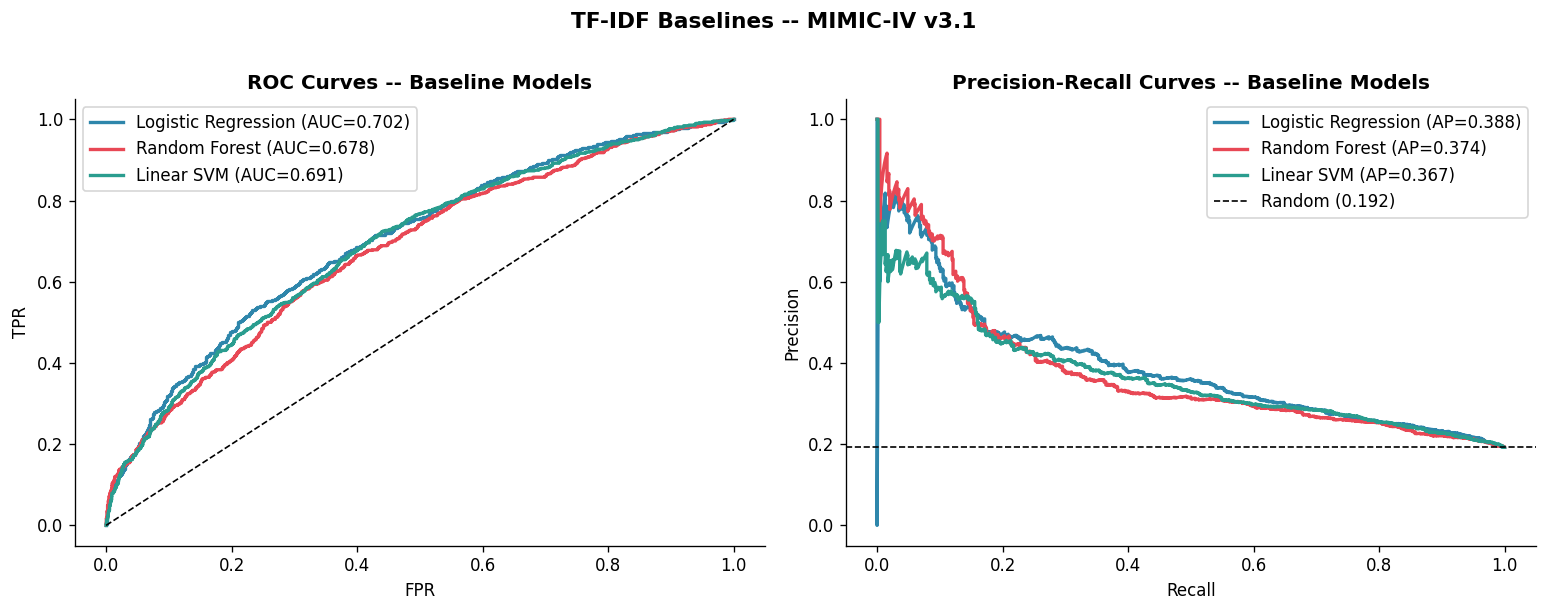

In [6]:
# Colour Mapping for Each Model
colors = {
    "Logistic Regression": "#2E86AB",
    "Random Forest": "#E84855",
    "Linear SVM": "#2A9D8F",
}

# ROC and Precision-Recall Curve Setup
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curve Plotting
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])

    axes[0].plot(
        fpr,
        tpr,
        label=f'{name} (AUC={res["roc_auc"]:.3f})',
        color=colors[name],
        lw=2,
    )

# Random Baseline (ROC)
axes[0].plot([0, 1], [0, 1], "k--", lw=1)

axes[0].set_title("ROC Curves -- Baseline Models", fontweight="bold")
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].legend()

# Precision-Recall Curve Plotting
baseline_pr = y_test.mean()

for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res["y_prob"])

    axes[1].plot(
        rec,
        prec,
        label=f'{name} (AP={res["pr_auc"]:.3f})',
        color=colors[name],
        lw=2,
    )

# Random Baseline (PR Curve)
axes[1].axhline(
    y=baseline_pr,
    color="k",
    linestyle="--",
    lw=1,
    label=f"Random ({baseline_pr:.3f})",
)

axes[1].set_title(
    "Precision-Recall Curves -- Baseline Models",
    fontweight="bold",
)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

# Figure Formatting and Save
plt.suptitle(
    "TF-IDF Baselines -- MIMIC-IV v3.1",
    fontsize=13,
    fontweight="bold",
    y=1.01,
)

plt.tight_layout()

plt.savefig(
    f"{BASELINE_MODEL_PLT}/base_01_roc_pr_curves.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## Confusion Matrix Comparison

This section visualises classification outcomes for each baseline model using confusion matrices.

- Computes confusion matrices for each model based on test predictions
- Displays class-wise prediction counts:
  - True positives, true negatives
  - False positives, false negatives
- Uses consistent labelling for:
  - Not readmitted
  - Readmitted
- Enables comparison of model performance across:
  - Classification accuracy
  - Error distribution
- Presents results in a side-by-side layout for clarity
- Saves visualisations for reporting and further analysis

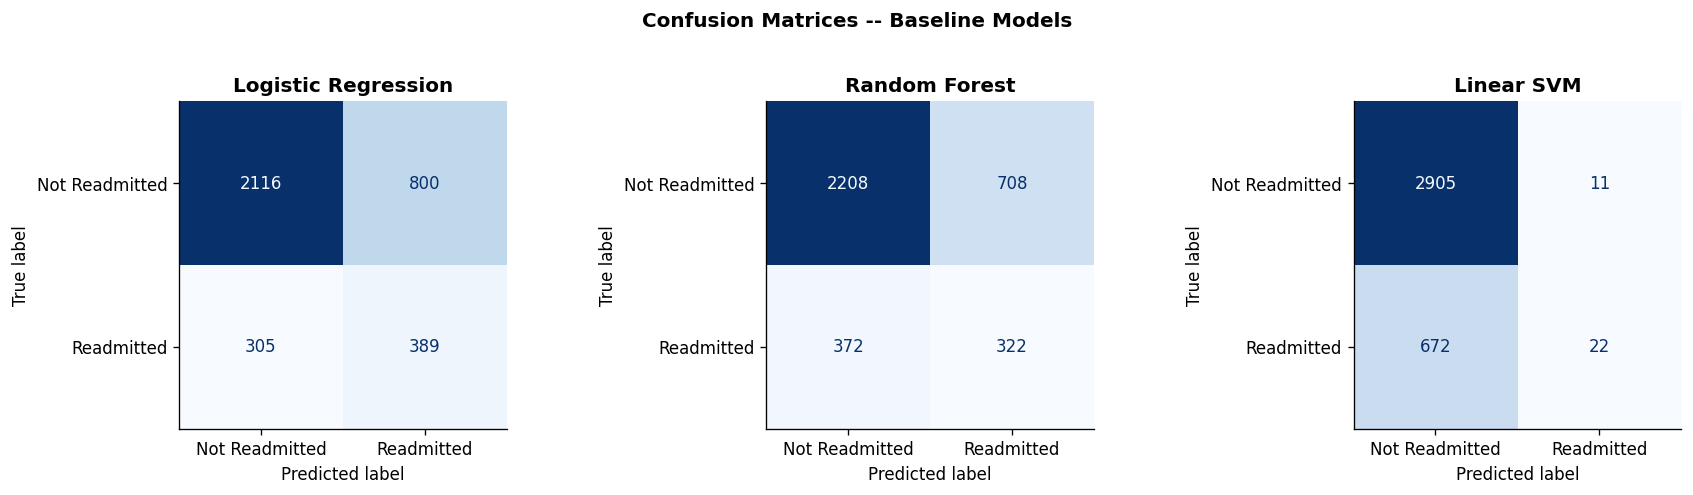

In [7]:
# Confusion Matrix Visualisation for Each Model
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Generate Confusion Matrix per Model
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])

    ConfusionMatrixDisplay(
        cm,
        display_labels=["Not Readmitted", "Readmitted"],
    ).plot(
        ax=ax,
        colorbar=False,
        cmap="Blues",
    )

    # Subplot Title (Model Name)
    ax.set_title(name, fontweight="bold")

# Figure Formatting and Save
plt.suptitle(
    "Confusion Matrices -- Baseline Models",
    fontsize=12,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()

plt.savefig(
    f"{BASELINE_MODEL_PLT}/base_02_confusion_matrices.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## Logistic Regression Feature Importance Analysis

This section analyses feature importance from the Logistic Regression model using learned coefficients.

- Extracts model coefficients associated with TF-IDF features
- Identifies:
  - Top positive coefficients (strong predictors of readmission)
  - Top negative coefficients (strong predictors of non-readmission)
- Maps coefficients to corresponding feature names
- Visualises the most influential features for each class:
  - Readmission predictors
  - Non-readmission predictors
- Uses coefficient magnitude to interpret feature importance
- Provides insight into key textual patterns driving model predictions
- Saves plots for reporting and interpretability analysis

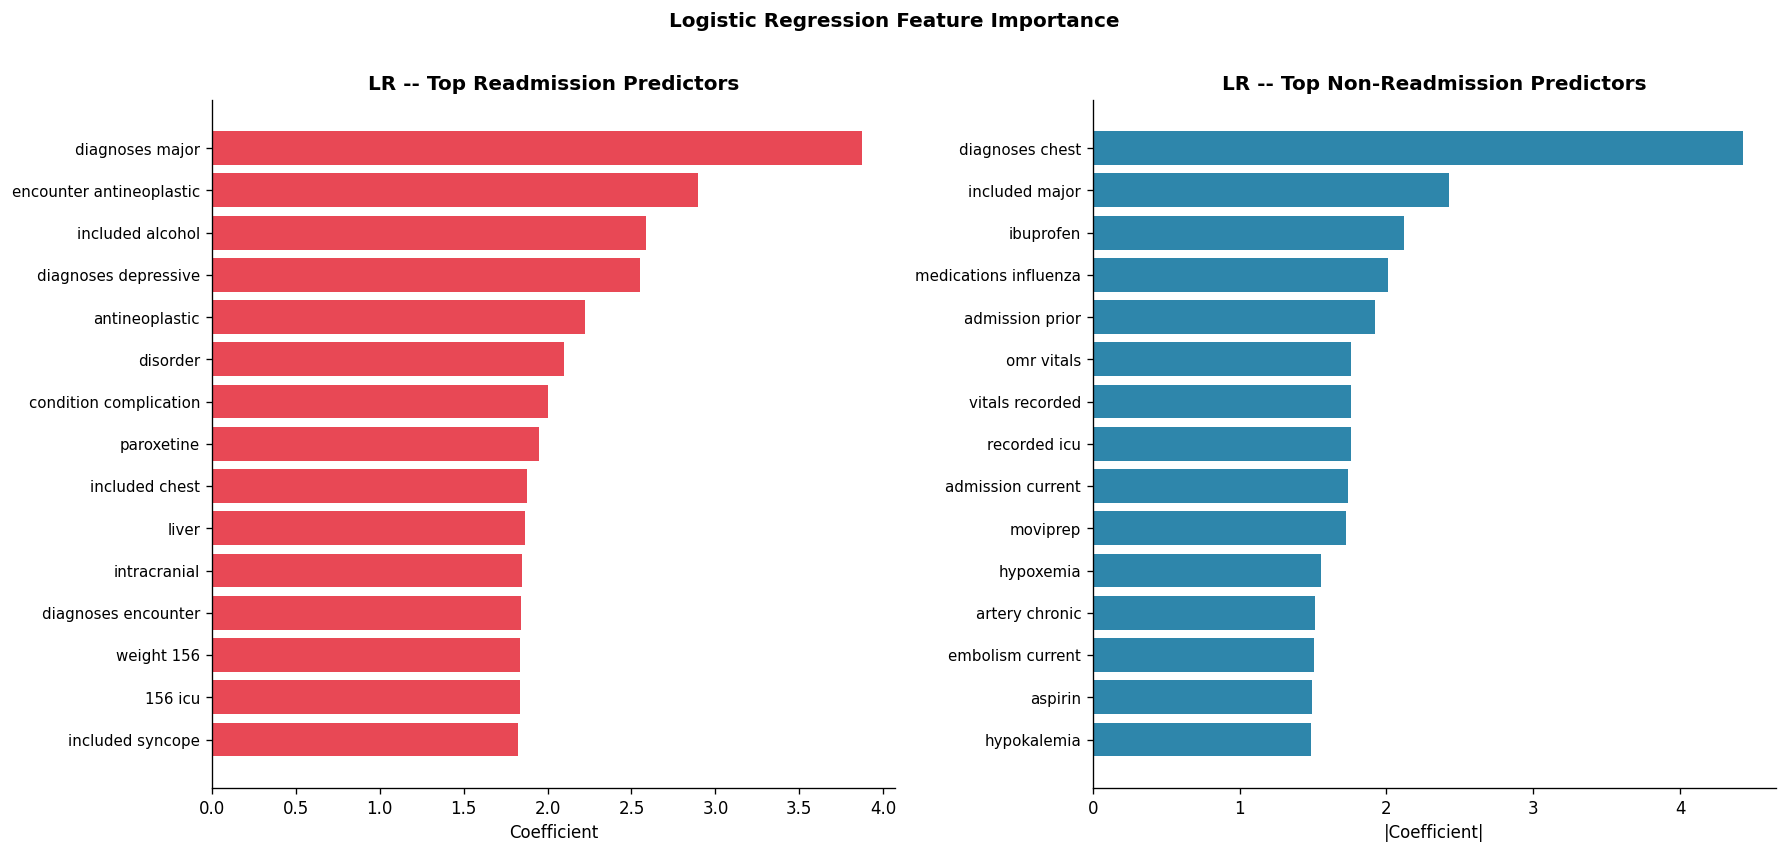

In [8]:
# Extract Trained Logistic Regression Model
lr_model = results["Logistic Regression"]["model"]

# Coefficients and Feature Names
coef       = lr_model.coef_[0]
feat_names = np.array(tfidf.get_feature_names_out())

# Top Positive and Negative Feature Indices
top_pos_idx = coef.argsort()[-20:][::-1]
top_neg_idx = coef.argsort()[:20]

# Feature Importance Plot Setup
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Top Positive Coefficients (Readmission Predictors)
axes[0].barh(
    range(15),
    coef[top_pos_idx[:15]][::-1],
    color=PALETTE[1],
)
axes[0].set_yticks(range(15))
axes[0].set_yticklabels(
    feat_names[top_pos_idx[:15]][::-1],
    fontsize=9,
)
axes[0].set_title(
    "LR -- Top Readmission Predictors",
    fontweight="bold",
)
axes[0].set_xlabel("Coefficient")

# Top Negative Coefficients (Non-Readmission Predictors)
axes[1].barh(
    range(15),
    abs(coef[top_neg_idx[:15]][::-1]),
    color=PALETTE[0],
)
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(
    feat_names[top_neg_idx[:15]][::-1],
    fontsize=9,
)
axes[1].set_title(
    "LR -- Top Non-Readmission Predictors",
    fontweight="bold",
)
axes[1].set_xlabel("|Coefficient|")

# Figure Formatting and Save
plt.suptitle(
    "Logistic Regression Feature Importance",
    fontsize=12,
    fontweight="bold",
    y=1.01,
)

plt.tight_layout()

plt.savefig(
    f"{BASELINE_MODEL_PLT}/base_03_lr_feature_importance.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## Model Comparison and Best Model Selection

This section aggregates evaluation metrics across baseline models and identifies the best-performing model.

- Compiles performance metrics for each model into a structured summary:
  - Accuracy
  - Precision, recall, and F1-score (positive class)
  - Weighted F1-score
  - ROC-AUC and PR-AUC
- Creates a summary DataFrame for comparison and reporting
- Saves results to a CSV file for reproducibility
- Identifies the best model based on highest ROC-AUC
- Serialises the best-performing model and associated artifacts:
  - Trained model
  - TF-IDF vectoriser
  - Test data predictions and probabilities
- Enables reuse of the best model for downstream evaluation or deployment

In [9]:
# Compile Evaluation Summary Across Models
summary_rows = []

for name, res in results.items():
    r = res["report"]

    # Collect Metrics for Each Model
    summary_rows.append(
        {
            "Model" : name,
            "Type" : "Baseline",
            "Accuracy" : r["accuracy"],
            "Precision_Pos": r["1"]["precision"],
            "Recall_Pos" : r["1"]["recall"],
            "F1_Pos" : r["1"]["f1-score"],
            "F1_Weighted" : r["weighted avg"]["f1-score"],
            "ROC_AUC" : res["roc_auc"],
            "PR_AUC" : res["pr_auc"],
        }
    )

# Create Summary DataFrame
summary_df = pd.DataFrame(summary_rows)

# Save Results to CSV
summary_df.to_csv(BASELINE_RESULTS_CSV, index=False)

print("Baseline results saved.")
print(summary_df.to_string(index=False, float_format="{:.4f}".format))

# Select Best Model (Based on ROC-AUC)
best_name = summary_df.loc[
    summary_df["ROC_AUC"].idxmax(),
    "Model"
]

best_res = results[best_name]

print(f"\nBest baseline: {best_name}")

# Save Best Model and Artifacts
with open(BEST_BASELINE_PKL, "wb") as f:
    pickle.dump(
        {
            "name" : best_name,
            "model" : best_res["model"],
            "tfidf" : tfidf,
            "y_test" : y_test,
            "y_pred" : best_res["y_pred"],
            "y_prob" : best_res["y_prob"],
        },
        f,
    )

Baseline results saved.
              Model     Type  Accuracy  Precision_Pos  Recall_Pos  F1_Pos  F1_Weighted  ROC_AUC  PR_AUC
Logistic Regression Baseline    0.6939         0.3272      0.5605  0.4132       0.7199   0.7021  0.3882
      Random Forest Baseline    0.7008         0.3126      0.4640  0.3735       0.7208   0.6776  0.3744
         Linear SVM Baseline    0.8108         0.6667      0.0317  0.0605       0.7344   0.6912  0.3666

Best baseline: Logistic Regression
